In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    15

In [4]:
df = pd.get_dummies(df, drop_first=True)

In [5]:
X = df[['Age']]     # independent variable
y = df['EstimatedSalary']   # dependent variable

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

y_pred2 = model2.predict(X_test_poly2)

print("Degree 2 R2 Score:", r2_score(y_test, y_pred2))
print("Degree 2 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))

Degree 2 R2 Score: 0.04163099447958396
Degree 2 RMSE: 31957.449729603468


In [8]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)

y_pred3 = model3.predict(X_test_poly3)

print("Degree 3 R2 Score:", r2_score(y_test, y_pred3))
print("Degree 3 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))

Degree 3 R2 Score: 0.03605597246277725
Degree 3 RMSE: 32050.26634442498


In [9]:
poly4 = PolynomialFeatures(degree=4)

X_train_poly4 = poly4.fit_transform(X_train)
X_test_poly4 = poly4.transform(X_test)

model4 = LinearRegression()
model4.fit(X_train_poly4, y_train)

y_pred4 = model4.predict(X_test_poly4)

print("Degree 4 R2 Score:", r2_score(y_test, y_pred4))
print("Degree 4 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred4)))

Degree 4 R2 Score: 0.0364897212635662
Degree 4 RMSE: 32043.05465557098


C:\Users\AbdulSamiAbbasi\AppData\Local\Temp\ipykernel_37580\111923142.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
C:\Users\AbdulSamiAbbasi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


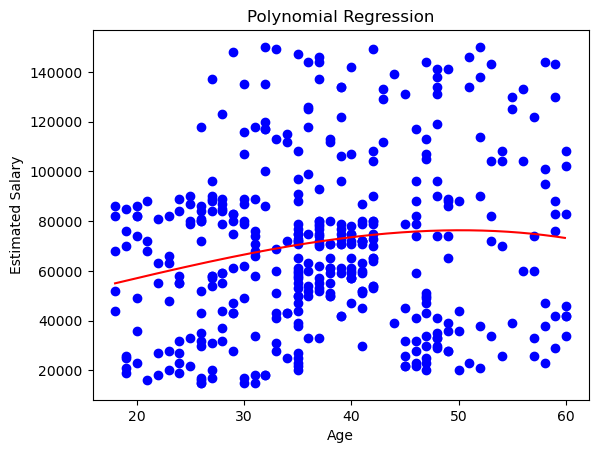

In [10]:
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)

plt.scatter(X, y, color='blue')

plt.plot(
    X_grid,
    model3.predict(poly3.transform(X_grid)),
    color='red'
)

plt.title("Polynomial Regression")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()